In [1]:
# 1. Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import xgboost as xgb
import joblib
import os
import tensorflow as tf



In [2]:
np.random.seed(42)
tf.random.set_seed(42)


In [3]:
# 2. Load Clean Dataset
# ============================================================
data = pd.read_csv("AirQuality_clean.csv")
data['Datetime'] = pd.to_datetime(data['Datetime'])
data = data.sort_values('Datetime')

print("✅ Data Loaded Successfully")
print(data.head())



✅ Data Loaded Successfully
    Datetime     CO(GT)  PT08.S1(CO)    NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  \
0 2004-03-10   1.966667  1316.500000   86.500000   8.450000     912.333333   
1 2004-03-11  -6.187500  1244.166667  104.500000   7.979167     851.958333   
2 2004-03-12 -14.095833  1281.666667  141.500000  12.129167    1008.291667   
3 2004-03-13  -5.750000  1330.666667  139.250000  10.916667     992.833333   
4 2004-03-14  -5.966667  1361.125000  116.958333   9.637500     943.916667   

      NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)          T  \
0  132.000000   1167.333333  108.833333   1545.500000  1096.000000  12.033333   
1  130.041667   1277.250000   87.375000   1522.833333   885.250000   9.837500   
2  142.583333   1101.875000   89.916667   1627.291667  1084.375000  11.287500   
3  168.416667    993.208333  105.583333   1595.791667  1245.916667  12.866667   
4  132.166667   1001.291667   97.458333   1602.375000  1234.208333  16.012500   

          RH     

In [4]:
# 3. Train-Test Split
# ============================================================
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:]
print(f"Train size: {len(train)} | Test size: {len(test)}")


Train size: 312 | Test size: 79


In [5]:
# 4. Train Models
# ============================================================

# ------------------- ARIMA -------------------
print("\nTraining ARIMA...")
arima_model = ARIMA(train['AQI'], order=(5,1,0))
arima_result = arima_model.fit()
arima_pred = arima_result.forecast(steps=len(test))



Training ARIMA...


In [6]:
# ------------------- Prophet -------------------
print("Training Prophet...")
prophet_df = data[['Datetime', 'AQI']].rename(columns={'Datetime': 'ds', 'AQI': 'y'})
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

prophet_model = Prophet()
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='H')
forecast = prophet_model.predict(future)
prophet_pred = forecast['yhat'].iloc[-len(test_prophet):].values


Training Prophet...


00:19:47 - cmdstanpy - INFO - Chain [1] start processing
00:19:57 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# ------------------- LSTM -------------------
print("Training LSTM...")
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data[['AQI']])
train_scaled = scaled[:train_size]
test_scaled = scaled[train_size:]

def create_sequences(data, steps=10):
    X, y = [], []
    for i in range(steps, len(data)):
        X.append(data[i-steps:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)  # ⬅ Increased epochs to 50

lstm_pred = model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred)



Training LSTM...
Epoch 1/50
19/19 [==============================] - 5s 28ms/step - loss: 0.6747
Epoch 2/50
19/19 [==============================] - 0s 15ms/step - loss: 0.2534
Epoch 3/50
19/19 [==============================] - 0s 16ms/step - loss: 0.1297
Epoch 4/50
19/19 [==============================] - 0s 18ms/step - loss: 0.1149
Epoch 5/50
19/19 [==============================] - 0s 13ms/step - loss: 0.1076
Epoch 6/50
19/19 [==============================] - 0s 15ms/step - loss: 0.1048
Epoch 7/50
19/19 [==============================] - 0s 15ms/step - loss: 0.1005
Epoch 8/50
19/19 [==============================] - 0s 21ms/step - loss: 0.0950
Epoch 9/50
19/19 [==============================] - 0s 12ms/step - loss: 0.0899
Epoch 10/50
19/19 [==============================] - 0s 13ms/step - loss: 0.0866
Epoch 11/50
19/19 [==============================] - 0s 12ms/step - loss: 0.0818
Epoch 12/50
19/19 [==============================] - 0s 12ms/step - loss: 0.0758
Epoch 13/50
19/19 [=

In [8]:
# ------------------- XGBoost -------------------
print("Training XGBoost...")
lags = 3
for i in range(1, lags + 1):
    data[f'lag_{i}'] = data['AQI'].shift(i)
data = data.dropna()

train = data.iloc[:train_size]
test = data.iloc[train_size:]
features = [f'lag_{i}' for i in range(1, lags + 1)]

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(train[features], train['AQI'])
xgb_pred = xgb_model.predict(test[features])



Training XGBoost...


In [9]:
# 5. Evaluate Models (Aligned)
# ============================================================
def align_and_evaluate(true, pred, model_name):
    true, pred = np.array(true), np.array(pred)
    min_len = min(len(true), len(pred))
    true, pred = true[-min_len:], pred[-min_len:]
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{model_name:<8} → MAE: {mae:.3f}, RMSE: {rmse:.3f}")
    return mae, rmse

results = {}
results['ARIMA']   = align_and_evaluate(test['AQI'], arima_pred, 'ARIMA')
results['Prophet'] = align_and_evaluate(test_prophet['y'], prophet_pred, 'Prophet')
results['LSTM']    = align_and_evaluate(test['AQI'], lstm_pred.flatten(), 'LSTM')
results['XGBoost'] = align_and_evaluate(test['AQI'], xgb_pred, 'XGBoost')

best_model = min(results, key=lambda x: results[x][1])
print(f"\n✅ Best Model: {best_model} with RMSE = {results[best_model][1]:.3f}")

ARIMA    → MAE: 539.757, RMSE: 1315.723
Prophet  → MAE: 1869.810, RMSE: 2038.449
LSTM     → MAE: 1189.824, RMSE: 1256.952
XGBoost  → MAE: 1261.887, RMSE: 2367.727

✅ Best Model: LSTM with RMSE = 1256.952


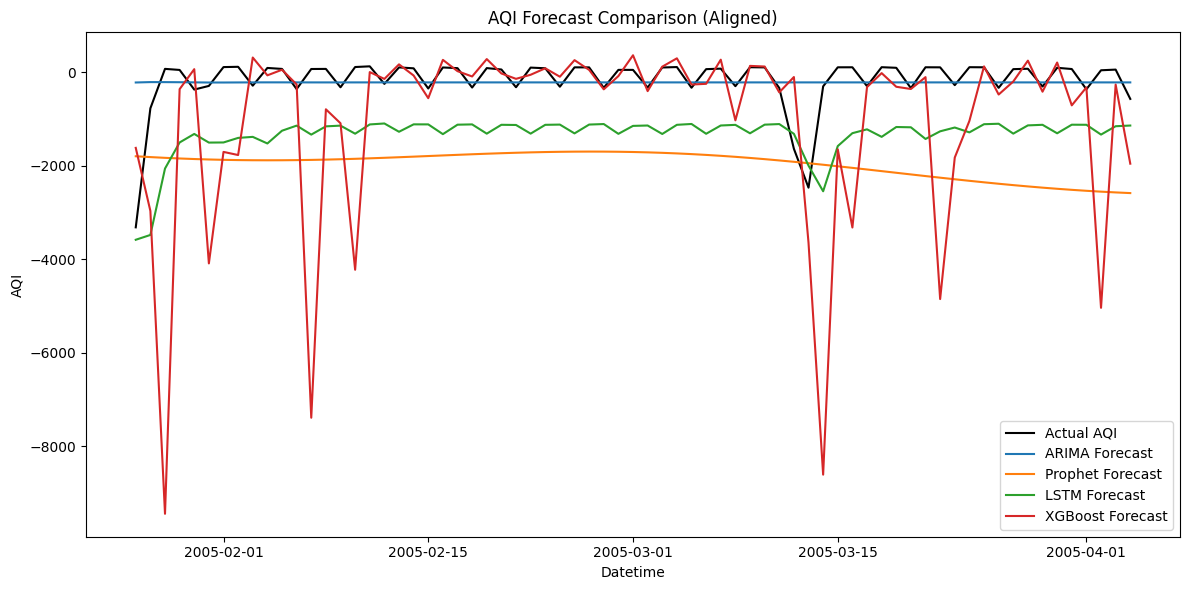

In [11]:
min_len = min(len(test), len(arima_pred), len(prophet_pred), len(lstm_pred), len(xgb_pred))

test_aligned = test.tail(min_len)
arima_pred = arima_pred[-min_len:]
prophet_pred = prophet_pred[-min_len:]
lstm_pred = lstm_pred[-min_len:]
xgb_pred = xgb_pred[-min_len:]
plt.figure(figsize=(12,6))
plt.plot(test_aligned['Datetime'], test_aligned['AQI'], label='Actual AQI', color='black')

plt.plot(test_aligned['Datetime'], arima_pred, label='ARIMA Forecast')
plt.plot(test_aligned['Datetime'], prophet_pred, label='Prophet Forecast')
plt.plot(test_aligned['Datetime'], lstm_pred, label='LSTM Forecast')
plt.plot(test_aligned['Datetime'], xgb_pred, label='XGBoost Forecast')

plt.title('AQI Forecast Comparison (Aligned)')
plt.xlabel('Datetime')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# 7. Save Best Model
# ============================================================
if best_model == 'ARIMA':
    joblib.dump(arima_result, 'best_model.pkl')
elif best_model == 'Prophet':
    joblib.dump(prophet_model, 'best_model.pkl')
elif best_model == 'LSTM':
    model.save('best_model_lstm.h5')
else:
    joblib.dump(xgb_model, 'best_model.pkl')

print(f"🎯 Best model ({best_model}) saved successfully!")


🎯 Best model (LSTM) saved successfully!
